In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import multiprocessing
# from multiprocess import Pool
import sys

from selectinf.group_lasso_query import (group_lasso,
                                         split_group_lasso)

from selectinf.Simulation.instance import (logistic_group_instance)

from selectinf.Simulation.test_logistic_group_lasso import (calculate_F1_score,
                                                            naive_inference,
                                                            randomization_inference,
                                                            split_inference, data_splitting)

In [34]:
def comparison_logistic_lasso_vary_p(n=500,
                                     s=10,
                                     signal_fac=1,
                                     sigma=2,
                                     rho=0.5,
                                     randomizer_scale=1.,
                                     full_dispersion=True,
                                     level=0.90,
                                     range=range(0,30)):
    """
    Compare to R randomized lasso
    """

    # Operating characteristics
    oper_char = {}
    oper_char["p"] = []
    oper_char["coverage rate"] = []
    oper_char["avg length"] = []
    oper_char["method"] = []
    oper_char["F1 score"] = []
    # oper_char["runtime"] = []

    confint_df = pd.DataFrame()

    for p in [100, 200, 300, 400]:#[200, 400, 600]:  # [0.01, 0.03, 0.06, 0.1]:
        for i in range:
            print(f"p={p}, {i}-th simulation")
            np.random.seed(i)

            inst, const, const_split = logistic_group_instance, group_lasso.logistic, \
                                       split_group_lasso.logistic
            signal = np.sqrt(signal_fac * 2 * np.log(p))
            signal_str = str(np.round(signal, decimals=2))

            while True:  # run until we get some selection
                groups = np.arange(p//4).repeat(4)
                X, Y, beta = inst(n=n,
                                  p=p,
                                  signal=signal,
                                  sgroup=s,
                                  groups=groups,
                                  ndiscrete=20,
                                  nlevels=5,
                                  sdiscrete=s - 3,  # s-3, # How many discrete rvs are not null
                                  equicorrelated=False,
                                  rho=rho,
                                  random_signs=True)[:3]
                # print(X)

                n, p = X.shape

                noselection = False  # flag for a certain method having an empty selected set

                if not noselection:
                    """# carving
                    coverage_s, length_s, beta_target_s, nonzero_s, \
                    selection_idx_s, hessian, conf_low_s, conf_up_s = \
                        split_inference(X=X, Y=Y, n=n, p=p,
                                        beta=beta, groups=groups, const=const_split,
                                        proportion=0.67)

                    noselection = (coverage_s is None)"""

                if not noselection:
                    # MLE inference
                    coverage, length, beta_target, nonzero, conf_low, conf_up = \
                        randomization_inference(X=X, Y=Y, n=n, p=p, proportion=0.67,
                                                use_iso=False,
                                                beta=beta, groups=groups, weight_frac=1.)
                    noselection = (coverage is None)

                if not noselection:
                    # data splitting
                    coverage_ds, lengths_ds, conf_low_ds, conf_up_ds, nonzero_ds, beta_target_ds = \
                        data_splitting(X=X, Y=Y, n=n, p=p, beta=beta, groups=groups,
                                       proportion=0.67, level=0.9, weight_frac=1)
                    noselection = (coverage_ds is None)

                if not noselection:
                    # naive inference
                    coverage_naive, lengths_naive, nonzero_naive, conf_low_naive, conf_up_naive, \
                    beta_target_naive = \
                        naive_inference(X=X, Y=Y, groups=groups,
                                        beta=beta, const=const,
                                        n=n, level=level, weight_frac=1.)
                    noselection = (coverage_naive is None)

                if not noselection:
                    # F1 scores
                    F1 = calculate_F1_score(beta, selection=nonzero)
                    F1_ds = calculate_F1_score(beta, selection=nonzero_ds)
                    F1_naive = calculate_F1_score(beta, selection=nonzero_naive)

                    # MLE coverage
                    oper_char["p"].append(p)
                    oper_char["coverage rate"].append(np.mean(coverage))
                    oper_char["avg length"].append(np.mean(length))
                    oper_char["F1 score"].append(F1)
                    oper_char["method"].append('MLE')
                    df_MLE = pd.concat([pd.DataFrame(np.ones(nonzero.sum()) * i),
                                        pd.DataFrame(beta_target),
                                        pd.DataFrame(conf_low),
                                        pd.DataFrame(conf_up),
                                        pd.DataFrame(beta[nonzero] != 0),
                                        pd.DataFrame(np.ones(nonzero.sum()) * s),
                                        pd.DataFrame(np.ones(nonzero.sum()) * F1),
                                        pd.DataFrame(["MLE"] * nonzero.sum())
                                        ], axis=1)
                    confint_df = pd.concat([confint_df, df_MLE], axis=0)

                    # Data splitting coverage
                    oper_char["p"].append(p)
                    oper_char["coverage rate"].append(np.mean(coverage_ds))
                    oper_char["avg length"].append(np.mean(lengths_ds))
                    oper_char["F1 score"].append(F1_ds)
                    oper_char["method"].append('Data splitting')
                    # oper_char["runtime"].append(0)
                    df_ds = pd.concat([pd.DataFrame(np.ones(nonzero_ds.sum()) * i),
                                       pd.DataFrame(beta_target_ds),
                                       pd.DataFrame(conf_low_ds),
                                       pd.DataFrame(conf_up_ds),
                                       pd.DataFrame(beta[nonzero_ds] != 0),
                                       pd.DataFrame(np.ones(nonzero_ds.sum()) * s),
                                       pd.DataFrame(np.ones(nonzero_ds.sum()) * F1_ds),
                                       pd.DataFrame(["Data splitting"] * nonzero_ds.sum())
                                       ], axis=1)
                    confint_df = pd.concat([confint_df, df_ds], axis=0)

                    # Naive coverage
                    oper_char["p"].append(p)
                    oper_char["coverage rate"].append(np.mean(coverage_naive))
                    oper_char["avg length"].append(np.mean(lengths_naive))
                    oper_char["F1 score"].append(F1_naive)
                    oper_char["method"].append('Naive')
                    df_naive = pd.concat([pd.DataFrame(np.ones(nonzero_naive.sum()) * i),
                                          pd.DataFrame(beta_target_naive),
                                          pd.DataFrame(conf_low_naive),
                                          pd.DataFrame(conf_up_naive),
                                          pd.DataFrame(beta[nonzero_naive] != 0),
                                          pd.DataFrame(np.ones(nonzero_naive.sum()) * s),
                                          pd.DataFrame(np.ones(nonzero_naive.sum()) * F1_naive),
                                          pd.DataFrame(["Naive"] * nonzero_naive.sum())
                                          ], axis=1)
                    confint_df = pd.concat([confint_df, df_naive], axis=0)

                    break  # Go to next iteration if we have some selection

    return oper_char

In [36]:
oper_char = comparison_logistic_lasso_vary_p(range=range(0,500))

p=100, 0-th simulation
p=100, 1-th simulation
p=100, 2-th simulation
p=100, 3-th simulation
p=100, 4-th simulation
p=100, 5-th simulation
p=100, 6-th simulation
p=100, 7-th simulation
p=100, 8-th simulation
p=100, 9-th simulation
p=100, 10-th simulation
p=100, 11-th simulation
p=100, 12-th simulation
p=100, 13-th simulation
p=100, 14-th simulation
p=100, 15-th simulation
p=100, 16-th simulation
p=100, 17-th simulation
p=100, 18-th simulation
p=100, 19-th simulation
p=100, 20-th simulation
p=100, 21-th simulation
p=100, 22-th simulation
p=100, 23-th simulation
p=100, 24-th simulation
p=100, 25-th simulation
p=100, 26-th simulation
p=100, 27-th simulation
p=100, 28-th simulation
p=100, 29-th simulation
p=100, 30-th simulation
p=100, 31-th simulation
p=100, 32-th simulation
p=100, 33-th simulation
p=100, 34-th simulation
p=100, 35-th simulation
p=100, 36-th simulation
p=100, 37-th simulation
p=100, 38-th simulation
p=100, 39-th simulation
p=100, 40-th simulation
p=100, 41-th simulation
p=

/Users/yilingh/Desktop/PhD/SI_Codes/G_LASSO_Final/PoSI-GroupLASSO/selectinf/Simulation/test_logistic_group_lasso.py:465: RuntimeWarning: overflow encountered in exp
  return np.exp(x) / (1 + np.exp(x)) ** 2
/Users/yilingh/Desktop/PhD/SI_Codes/G_LASSO_Final/PoSI-GroupLASSO/selectinf/Simulation/test_logistic_group_lasso.py:465: RuntimeWarning: overflow encountered in square
  return np.exp(x) / (1 + np.exp(x)) ** 2
/Users/yilingh/Desktop/PhD/SI_Codes/G_LASSO_Final/PoSI-GroupLASSO/selectinf/Simulation/test_logistic_group_lasso.py:465: RuntimeWarning: invalid value encountered in divide
  return np.exp(x) / (1 + np.exp(x)) ** 2


p=400, 97-th simulation
p=400, 98-th simulation
p=400, 99-th simulation
p=400, 100-th simulation
p=400, 101-th simulation
p=400, 102-th simulation
p=400, 103-th simulation
p=400, 104-th simulation
p=400, 105-th simulation
p=400, 106-th simulation
p=400, 107-th simulation
p=400, 108-th simulation
p=400, 109-th simulation
p=400, 110-th simulation
p=400, 111-th simulation
p=400, 112-th simulation
p=400, 113-th simulation
p=400, 114-th simulation
p=400, 115-th simulation
p=400, 116-th simulation
p=400, 117-th simulation
p=400, 118-th simulation
p=400, 119-th simulation
p=400, 120-th simulation
p=400, 121-th simulation
p=400, 122-th simulation
p=400, 123-th simulation
p=400, 124-th simulation
p=400, 125-th simulation
p=400, 126-th simulation
p=400, 127-th simulation
p=400, 128-th simulation
p=400, 129-th simulation
p=400, 130-th simulation
p=400, 131-th simulation
p=400, 132-th simulation
p=400, 133-th simulation
p=400, 134-th simulation
p=400, 135-th simulation
p=400, 136-th simulation
p=4

In [37]:
pd.DataFrame(oper_char).groupby(['method', 'p']).mean()

coverage rate  avg length  F1 score
method         p                                       
Data splitting 100       0.874131   17.349559  0.577028
               200       0.877174   17.648591  0.529588
               300       0.864939   17.911879  0.512410
               400       0.864826   18.210336  0.495968
MLE            100       0.900794   12.775215  0.644089
               200       0.891093   12.693083  0.568405
               300       0.884833   12.689460  0.531471
               400       0.881783   12.764637  0.494396
Naive          100       0.851896    9.221634  0.681659
               200       0.850640    9.362152  0.657181
               300       0.842837    9.407165  0.635326
               400       0.848244    9.541769  0.631052

In [38]:
def plotting(oper_char):
    oper_char_df = pd.DataFrame(oper_char)
    # sns.histplot(oper_char_df["sparsity size"])
    # plt.show()

    fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))

    print("Mean coverage rate/length:")
    print(oper_char_df.groupby(['p', 'method']).mean())

    cov_plot = sns.boxplot(y=oper_char_df["coverage rate"],
                           x=oper_char_df["p"],
                           hue=oper_char_df["method"],
                           palette="pastel",
                           orient="v", ax=ax1,
                           linewidth=1, showmeans=True)
    cov_plot.set(title='Coverage')
    cov_plot.set_ylim(0.6, 1.05)
    # plt.tight_layout()
    cov_plot.axhline(y=0.9, color='k', linestyle='--', linewidth=1)
    # ax1.set_ylabel("")  # remove y label, but keep ticks

    len_plot = sns.boxplot(y=oper_char_df["avg length"],
                           x=oper_char_df["p"],
                           hue=oper_char_df["method"],
                           palette="pastel",
                           orient="v", ax=ax2,
                           linewidth=1, showmeans=True)
    len_plot.set(title='Length')
    # len_plot.set_ylim(0, 100)
    # len_plot.set_ylim(0, 8)
    # plt.tight_layout()
    # ax2.set_ylabel("")  # remove y label, but keep ticks

    handles, labels = ax2.get_legend_handles_labels()
    # fig.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.2)
    fig.subplots_adjust(bottom=0.2)
    fig.legend(handles, labels, loc='lower center', ncol=4)

    F1_plot = sns.boxplot(y=oper_char_df["F1 score"],
                          x=oper_char_df["p"],
                          hue=oper_char_df["method"],
                          palette="pastel",
                          orient="v", ax=ax3,
                          linewidth=1, showmeans=True)
    F1_plot.set(title='F1 score')

    cov_plot.legend_.remove()
    len_plot.legend_.remove()
    F1_plot.legend_.remove()

    plt.show()

Mean coverage rate/length:
                    coverage rate  avg length  F1 score
p   method                                             
100 Data splitting       0.874131   17.349559  0.577028
    MLE                  0.900794   12.775215  0.644089
    Naive                0.851896    9.221634  0.681659
200 Data splitting       0.877174   17.648591  0.529588
    MLE                  0.891093   12.693083  0.568405
    Naive                0.850640    9.362152  0.657181
300 Data splitting       0.864939   17.911879  0.512410
    MLE                  0.884833   12.689460  0.531471
    Naive                0.842837    9.407165  0.635326
400 Data splitting       0.864826   18.210336  0.495968
    MLE                  0.881783   12.764637  0.494396
    Naive                0.848244    9.541769  0.631052


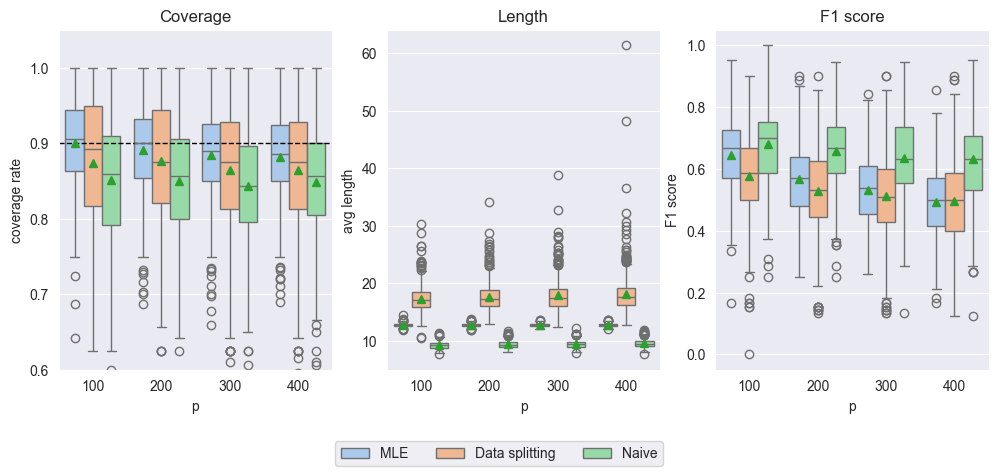

In [39]:
plotting(oper_char)

In [40]:
oper_char_df = pd.DataFrame(oper_char)

In [45]:
oper_char_df.to_csv('logistic_vary_p.csv', index=False)